In [170]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [171]:
data = pd.read_csv('amazon_baby.csv', engine='python', on_bad_lines='skip')

In [172]:
data.iloc[6670]

name                      Leachco Snoogle Total Body Pillow
review    I am currently pregnant with twins. I got this...
rating                                                    4
Name: 6670, dtype: object

In [173]:
data.head()

,name,review,rating
0,Planetwise Flannel Wipes,"These flannel wipes are OK, but in my opinion ...",3
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5


In [174]:
from collections import Counter


text = data['review'].astype(str)
data['word_counts'] = text.apply(lambda x: Counter(x.lower().split()))

In [175]:
data['word_counts'].head()

0    {'these': 1, 'flannel': 1, 'wipes': 2, 'are': ...
1    {'it': 2, 'came': 1, 'early': 1, 'and': 3, 'wa...
2    {'very': 1, 'soft': 1, 'and': 2, 'comfortable'...
3    {'this': 3, 'is': 4, 'a': 2, 'product': 2, 'we...
4    {'all': 2, 'of': 1, 'my': 1, 'kids': 2, 'have'...
Name: word_counts, dtype: object

In [176]:
import seaborn as sns

<Axes: xlabel='rating', ylabel='Count'>

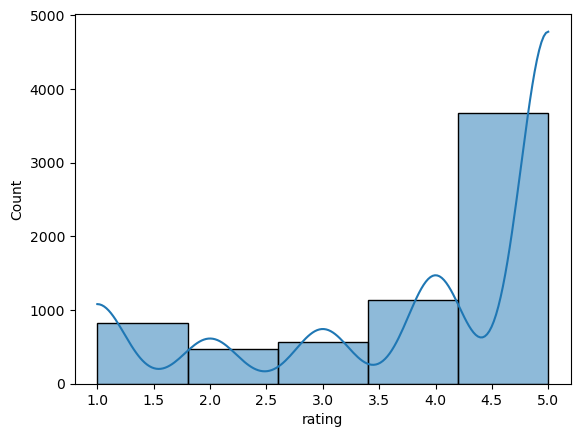

In [177]:
sns.histplot(data['rating'], bins=5, kde=True)

In [178]:
products_low_review = data[data['rating'] == 1]['name'].value_counts().tail(15)
products_low_review

name
Sassy Baby Large, Medium, And Small Feeding Bowl Set, Colors May Vary        1
Carry On Sling Carrier - Large/Extra-Large                                   1
Peg Perego Prima Pappa Multi-Position Dual Fabric High Chair - Chesapeake    1
Fisher-Price Sounds'n Lights Monitor                                         1
Philips AVENT BPA Free Toddler Cup with Handles, 7 Ounce, Color May Vary     1
Koala Baby Luxe Blanket in Blue                                              1
Safety 1st All in One Child Care Kit                                         1
Summer Infant Complete Nursery Care Kit                                      1
Summer Infant Digital Ear Thermometer Set                                    1
Regal Lager Diaper Dekor                                                     1
Diaper Dekor 3 Pack Refill                                                   1
Playtex Insulator/Playtime Cup, 9 Ounce, Colors May Vary                     1
Evenflo Comfort Ease Manual Breast Pump        

<Axes: ylabel='name'>

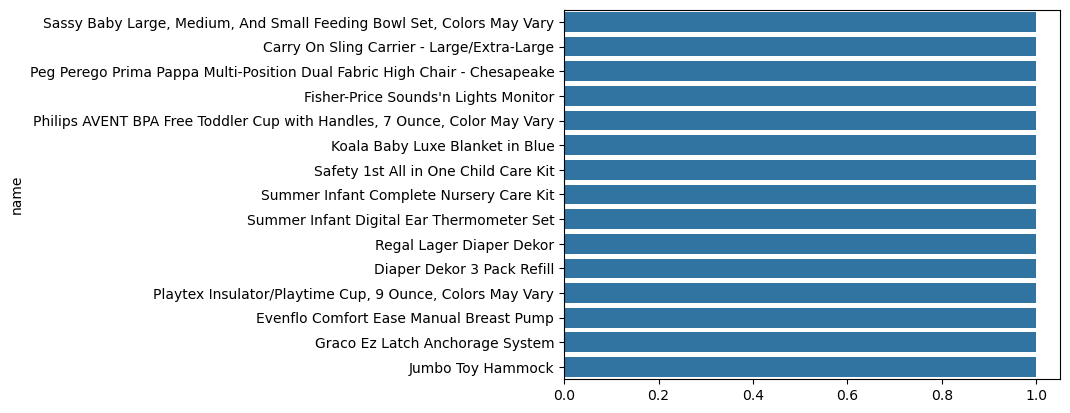

In [179]:
sns.barplot(x=products_low_review.values, y=products_low_review.index)

In [180]:
products = data['name'].value_counts()
top_products = products.head(15)
top_products

name
Baby Trend Diaper Champ                                                333
BABYBJORN Potty Chair - Red                                            232
Munchkin Mozart Magic Cube                                             191
Philips Avent 3 Pack 9oz Bottles                                       191
PRIMO EuroBath, Pearl White                                            182
The First Years Hands Free Gate                                        181
Safety 1st Deluxe 4-in-1 Bath Station                                  154
BABYBJORN Toilet Trainer - White/Red                                   139
Graco TotBloc Pack 'N Play with Carry Bag, Bugs Quilt                  139
The First Years Babypro Quick Serve Bottle Warmer, Colors May Vary     136
Leachco Safer Bather Infant Bath Pad, Blue Fish                        131
Diaper Dekor Plus Diaper Disposal System                               126
Leachco Snoogle Total Body Pillow                                      113
Playtex 3 Pack VentA

In [181]:
top_5star_products = data[data['rating'] == 5]['name'].value_counts().head(15)
top_5star_products

name
Baby Trend Diaper Champ                                               189
BABYBJORN Potty Chair - Red                                           174
PRIMO EuroBath, Pearl White                                           142
Munchkin Mozart Magic Cube                                            128
The First Years Hands Free Gate                                       128
BABYBJORN Toilet Trainer - White/Red                                  112
Graco TotBloc Pack 'N Play with Carry Bag, Bugs Quilt                 109
Leachco Safer Bather Infant Bath Pad, Blue Fish                        99
Leachco Snoogle Total Body Pillow                                      71
Philips Avent 3 Pack 9oz Bottles                                       66
Diaper Dekor Plus Diaper Disposal System                               64
BABYBJORN Safe Step - Blue                                             58
The First Years Babypro Quick Serve Bottle Warmer, Colors May Vary     56
BABYBJORN Original Carrier - City

<Axes: ylabel='name'>

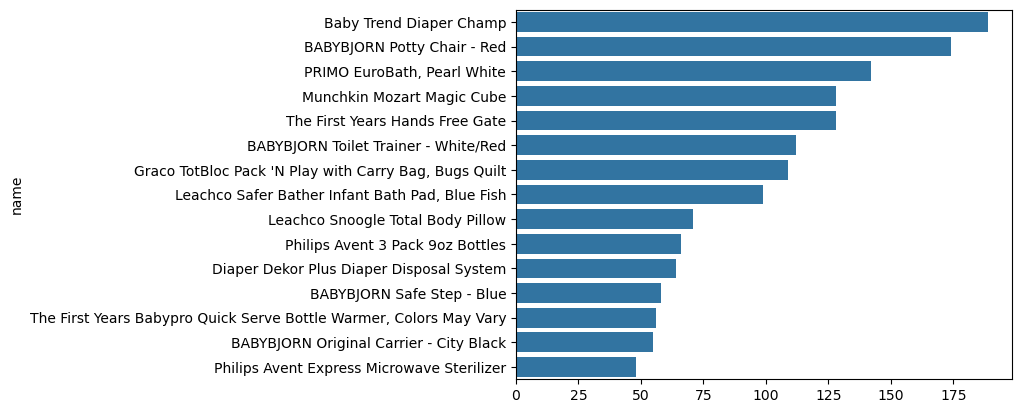

In [182]:
sns.barplot(x=top_5star_products.values, y=top_5star_products.index)

<Axes: ylabel='name'>

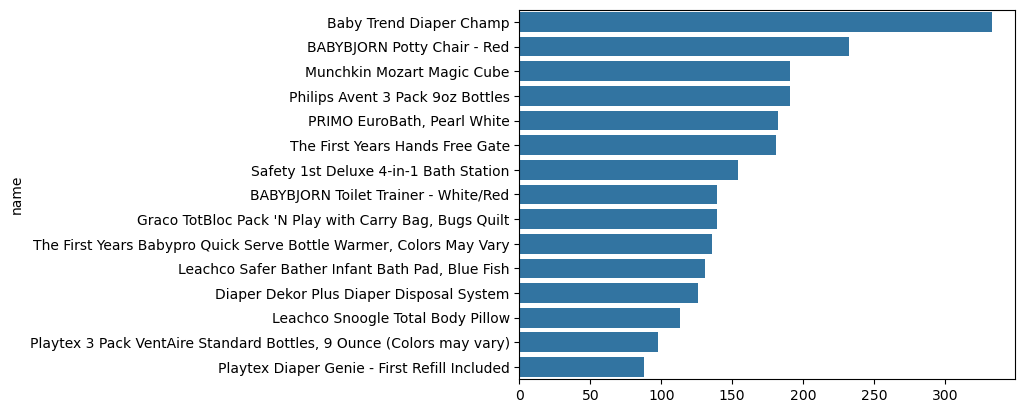

In [183]:
sns.barplot(x=top_products.values, y=top_products.index)

In [184]:
data_copy = data[data['rating'] != 3]

In [185]:
data_copy.head()

,name,review,rating,word_counts
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5,"{'it': 2, 'came': 1, 'early': 1, 'and': 3, 'wa..."
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5,"{'very': 1, 'soft': 1, 'and': 2, 'comfortable'..."
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5,"{'this': 3, 'is': 4, 'a': 2, 'product': 2, 'we..."
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5,"{'all': 2, 'of': 1, 'my': 1, 'kids': 2, 'have'..."
5,Stop Pacifier Sucking without tears with Thumb...,"When the Binky Fairy came to our house, we did...",5,"{'when': 2, 'the': 6, 'binky': 3, 'fairy': 3, ..."


In [186]:
data_copy[data_copy['rating'] == 3]

,name,review,rating,word_counts


In [187]:
data = data_copy

In [188]:
data.head()

,name,review,rating,word_counts
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5,"{'it': 2, 'came': 1, 'early': 1, 'and': 3, 'wa..."
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5,"{'very': 1, 'soft': 1, 'and': 2, 'comfortable'..."
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5,"{'this': 3, 'is': 4, 'a': 2, 'product': 2, 'we..."
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5,"{'all': 2, 'of': 1, 'my': 1, 'kids': 2, 'have'..."
5,Stop Pacifier Sucking without tears with Thumb...,"When the Binky Fairy came to our house, we did...",5,"{'when': 2, 'the': 6, 'binky': 3, 'fairy': 3, ..."


In [189]:
data['sentiment'] = data['rating'] >= 4

In [190]:
data['sentiment'].value_counts()

sentiment
True     4800
False    1301
Name: count, dtype: int64

<Axes: xlabel='sentiment', ylabel='Count'>

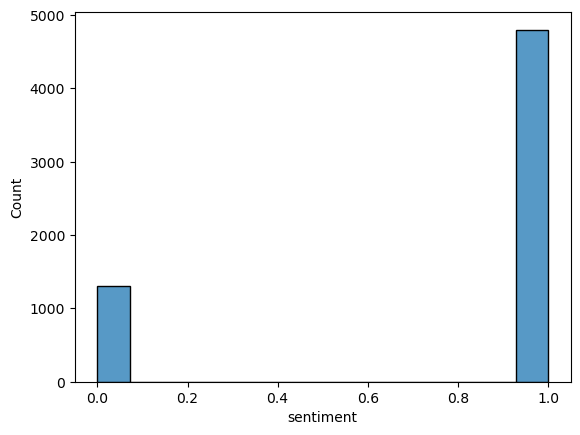

In [191]:
sns.histplot(data['sentiment'])

In [192]:
data.head()

,name,review,rating,word_counts,sentiment
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5,"{'it': 2, 'came': 1, 'early': 1, 'and': 3, 'wa...",True
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5,"{'very': 1, 'soft': 1, 'and': 2, 'comfortable'...",True
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5,"{'this': 3, 'is': 4, 'a': 2, 'product': 2, 'we...",True
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5,"{'all': 2, 'of': 1, 'my': 1, 'kids': 2, 'have'...",True
5,Stop Pacifier Sucking without tears with Thumb...,"When the Binky Fairy came to our house, we did...",5,"{'when': 2, 'the': 6, 'binky': 3, 'fairy': 3, ...",True


In [193]:
lc = LabelEncoder()

In [194]:
data['sentiment'] = lc.fit_transform(data['sentiment'])

In [195]:
data['sentiment'].value_counts()

sentiment
1    4800
0    1301
Name: count, dtype: int64

In [284]:
x = data['word_counts']
x

1       {'it': 2, 'came': 1, 'early': 1, 'and': 3, 'wa...
2       {'very': 1, 'soft': 1, 'and': 2, 'comfortable'...
3       {'this': 3, 'is': 4, 'a': 2, 'product': 2, 'we...
4       {'all': 2, 'of': 1, 'my': 1, 'kids': 2, 'have'...
5       {'when': 2, 'the': 6, 'binky': 3, 'fairy': 3, ...
                              ...                        
6666    {'this': 2, 'pillow': 4, 'saved': 1, 'me!': 1,...
6667    {'after': 1, 'having': 2, 'a': 3, 'total': 1, ...
6668    {'i': 1, 'had': 1, 'gained': 1, '60': 1, 'lbs'...
6669    {'why': 1, 'did': 1, 'i': 5, 'wait': 1, 'until...
6670    {'i': 4, 'am': 1, 'currently': 1, 'pregnant': ...
Name: word_counts, Length: 6085, dtype: object

In [285]:
victorize = DictVectorizer()
x = victorize.fit_transform(x)


In [116]:
data.head()

1    it came early and was not disappointed. i love...
2    Very soft and comfortable and warmer than it l...
3    This is a product well worth the purchase.  I ...
4    All of my kids have cried non-stop when I trie...
5    When the Binky Fairy came to our house, we did...
Name: review, dtype: object

In [238]:
data.isnull().sum()

name           0
review         0
rating         0
word_counts    0
sentiment      0
dtype: int64

In [229]:
data = data.dropna()

In [254]:
tf_idf = TfidfVectorizer(ngram_range=(1,2), max_features=20000)


x_1 = tf_idf.fit_transform(data['review']) 

In [322]:
from sklearn.feature_extraction.text import CountVectorizer

vector = CountVectorizer()
x_2 = vector.fit_transform(data['review'])

In [323]:
y = data['sentiment']

In [324]:
x_train, x_test, y_train, y_test = train_test_split(x_2, y, random_state=42, test_size=.2)

In [325]:
model = LogisticRegression( max_iter=2000, random_state=42)
model.fit(x_train, y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [326]:
y_pred = model.predict(x_test)

In [277]:
from sklearn.metrics import accuracy_score

In [327]:
print(accuracy_score(y_test, y_pred))

0.8907148726376335
